## Driver Fatigue Detection (Safety System)

<h3>Driver Monitoring Features</h3>

<small>

For each <i>driver snapshot</i>, the following features are extracted and analyzed:

| **Feature** | **Symbol** | **Description** |
|---|---|---|
| **Eye Closure Duration** | *x₁* | Duration for which the driver’s eyes remain closed *(in seconds)* |
| **Blink Rate** | *x₂* | Number of blinks detected per minute *(blinks/min)* |
| **Steering Variability** | *x₃* | Standard deviation of steering wheel movement |
| **Lane Deviation** | *x₄* | Distance of vehicle deviation from the lane center *(in meters)* |

</small>

In [40]:
import numpy as np
import matplotlib.pyplot as plt


# Dataset
X = np.array([
    [0.2, 15, 0.10, 0.2],
    [0.3, 18, 0.15, 0.3],
    [0.1, 20, 0.08, 0.1],
    [0.4, 17, 0.20, 0.4],
    [0.2, 22, 0.12, 0.2],
    [0.3, 19, 0.18, 0.3],

    [1.2, 8, 0.60, 1.5],
    [1.5, 6, 0.80, 1.8],
    [1.8, 5, 1.00, 2.0],
    [1.3, 7, 0.70, 1.6],
    [1.6, 6, 0.90, 1.9],
    [1.4, 7, 0.85, 1.7]
])

y = np.array([
    -1,-1,-1,-1,-1,-1,
     1, 1, 1, 1, 1, 1
])

In [41]:
# Normalize the features
X_scale = (X-X.mean())/X.std()

In [42]:
w = np.zeros(4)
b = 0
learning_rate = 0.5
epochs = 100

In [43]:
def predict(x):
    z = np.dot(w,x) + b

    if z>=0:
        return 1
    else:
        return -1

In [44]:
# Perceptron Algo
for epoch in range(epochs):
    errors=0

    for i in range(len(X_scale)):
        pred = predict(X_scale[i])

        if pred!=y[i]:
            w += learning_rate* X_scale[i]*y[i]
            b += learning_rate* y[i]
            errors+=1

    if errors==0:
        print(f"Converged at {epoch} epoch")
        break 

Converged at 1 epoch


In [45]:
# Final weights and bias
print("Weights: ",w)
print("Bias: ",b)

Weights:  [-0.10092984 -0.39337918 -0.20119818 -0.05079567]
Bias:  0.5


In [46]:
# Accuracy of the model
correct = 0
for i in range(len(X_scale)):
    pred = predict(X_scale[i])

    if pred==y[i]:
        correct+=1

print(f"Accuracy: {correct/len(X_scale)}")

Accuracy: 1.0


In [47]:
# Test Case
test = np.array([1.4, 7, 0.75, 1.7])
test_scaled = (test - X.mean(axis=0)) / X.std(axis=0)

print("Prediction:", predict(test_scaled))

Prediction: 1


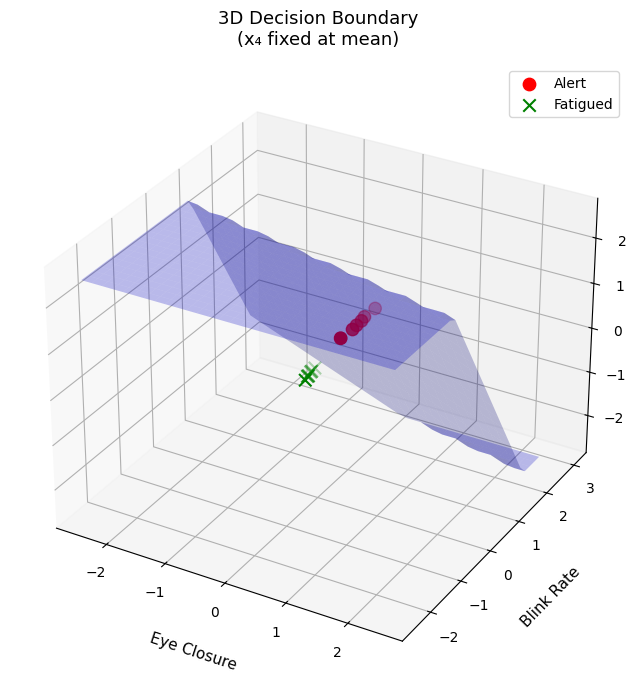

In [73]:
# Plotting the decision boundary using 3d slice because 4 features cannot be plotted. Keeping one feature constant.

# x-axis  -> Eye Closure
# y-axis  -> Steering Variability
# z-axis  -> Lane Deviation

w1, w2, w3, w4 = w
fig = plt.figure(figsize=(11, 7))
ax  = fig.add_subplot(111, projection='3d')

# ── Data points ───────────────────────────────────────────────
ax.scatter(X_scale[y==-1][:,0],
            X_scale[y==-1][:,1],
            X_scale[y==-1][:,2],
            color='red', marker='o', s=80,
            label='Alert', depthshade=True)

ax.scatter(X_scale[y==1][:,0],
            X_scale[y==1][:,1],
            X_scale[y==1][:,2],
            color='green', marker='x', s=80,
            label='Fatigued', depthshade=True)

# ── Decision boundary plane ───────────────────────────────────
# Full boundary: w1*x1 + w2*x2 + w3*x3 + w4*x4 + b = 0
# Fix x4 = 0 (mean after normalization)
# → w1*x1 + w2*x2 + w3*x3 + b = 0
# → x3 = -(w1*x1 + w2*x2 + b) / w3

x1_range = np.linspace(-2.5, 2.5, 30)
x2_range = np.linspace(-2.5, 2.5, 30)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Solve for x3 on the boundary
x3_grid = -(w1 * x1_grid + w2 * x2_grid + b) / w3

# Clip so plane stays within visible range
x3_grid = np.clip(x3_grid, -2.5, 2.5)

ax.plot_surface(x1_grid, x2_grid, x3_grid,alpha=0.25, color='blue')

# ── Labels ────────────────────────────────────────────────────
ax.set_xlabel("Eye Closure",       fontsize=11, labelpad=14)
ax.set_ylabel("Blink Rate",      fontsize=11, labelpad=14)
ax.set_zlabel("Steering Variability",     fontsize=11, labelpad=14)
ax.set_title("3D Decision Boundary\n(x₄ fixed at mean)",
                 fontsize=13, pad=14)

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
